In [1]:
from pathlib import Path
import sys

# Add the project root directory to sys.path
sys.path.append(str(Path().resolve().parent))
from src.constants.paths import SECRET_PATH


from src.processing.pde_ple import PDE, PLE, es
from src.processing.document import Document

# get all paths
from src.constants.constants import (
    USEFUL_EXTENSIONS,
    ENVIRONNEMENT_PATH,
    S3_RAW_DOCS_PATH,
    SERVICES_PATH,
    ENVIRONNEMENT_RAW_PATH,
)
import pandas as pd
from src.processing.utils import *


/opt/app-root/src/uc202-ipn-rex/.venv/lib/python3.11/site-packages/elasticsearch/_sync/client/__init__.py:397: SecurityWarning: Connecting to 'https://noeyyalp.noe.edf.fr:29203' using TLS with verify_certs=False is insecure
  _transport = transport_class(


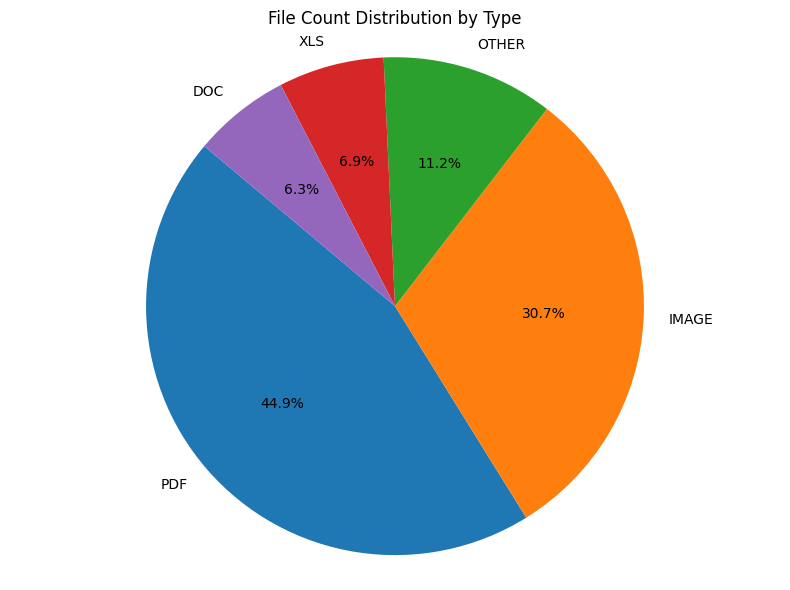

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data as a DataFrame
data = {
    "Grouped Extension": ["PDF", "IMAGE", "OTHER", "XLS", "DOC"],
    "Count": [4202639, 2871661, 1045120, 641552, 588871],
    "Total Size (GB)": [1281.67, 446.85, 482.41, 124.78, 69.41],
}
df = pd.DataFrame(data)

# Pie chart by count
plt.figure(figsize=(8, 6))
plt.pie(df["Count"], labels=df["Grouped Extension"], autopct="%1.1f%%", startangle=140)
plt.title("File Count Distribution by Type")
plt.axis("equal")
plt.tight_layout()
plt.show()


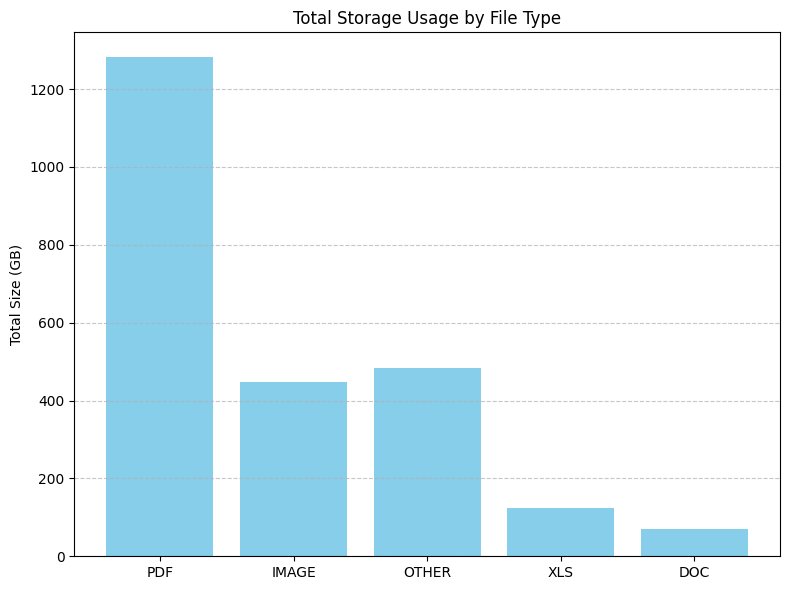

In [5]:
# Bar chart by total size
plt.figure(figsize=(8, 6))
plt.bar(df["Grouped Extension"], df["Total Size (GB)"], color="skyblue")
plt.ylabel("Total Size (GB)")
plt.title("Total Storage Usage by File Type")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [2]:
file_paths = PDE.s3.list_objects(S3_RAW_DOCS_PATH)
index_name = "uc202-rex"

In [31]:
es.indices.create(index="uc202-rex")


/opt/app-root/src/uc202-ipn-rex/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'noeyyalp.noe.edf.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'uc202-rex'})

In [27]:
df = PDE.s3.read_dataframe(
    path="s3://bkt-pud-uc/uc202-rex/dipnn-fla3/Archives-Temporaires.010/24-BASE-DONNEES.024/3-Export_RITM1937379 EXPORTS POUR DATA IA FACTORY/N1 Services 004/G-Environnement.007.csv",
    file_format="csv",
    encoding="Windows-1252",
    sep=";",
    header=1,
)

In [28]:
df = df[df["Type extension de fichier"].isin(USEFUL_EXTENSIONS)]

In [29]:
df["txt_file_name"] = df.apply(
    lambda row: str(row["Nom titre du fichier"])
    .lower()
    .replace(str(row["Type extension de fichier"]).lower(), ".txt"),
    axis=1,
)


In [14]:
duplicates.columns

Index(['filename', 'extension', 'date_creation', 'date_modification', 'auteur',
       'chemin', 'taille', 'txt_file_name'],
      dtype='object')

In [ ]:
# Step 1: Find duplicates based on the "txt_file_name" column
duplicates = df[df.duplicated(subset="filename", keep=False)]

# Step 2: Filter those duplicates to ensure "Taille du fichier" is different
different_size_duplicates = duplicates[
    duplicates.duplicated(subset="filename", keep=False)
    & ~duplicates.duplicated(subset=["filename", "taille"], keep=False)
]

# Sort the resulting DataFrame by the "txt_file_name" column
different_size_duplicates_sorted = different_size_duplicates.sort_values(
    by="txt_file_name"
)

different_size_duplicates_sorted.to_csv('.csv')


In [30]:
import os
import pandas as pd

# Créer txt_file_name
df["txt_file_name"] = df["Nom titre du fichier"].apply(lambda x: x.lower() + ".txt")


# Renommer les colonnes
df.rename(
    columns={
        "Nom titre du fichier": "filename",
        "Type extension de fichier": "extension",
        "Date de création du fichier": "date_creation",
        "Date de dernière modification": "date_modification",
        "Nom du créateur/dernier modificateur": "auteur",
        "Chemin d'accès": "chemin",
        "Taille du fichier": "taille",
    },
    inplace=True,
)
df = df.drop_duplicates(subset="filename", keep="last")
# Créer une clé unique basée sur filename + chemin


# Construire le dictionnaire de métadonnées avec la clé composite
metadata_dict = df.set_index("filename")[
    ["extension", "date_creation", "date_modification", "auteur", "chemin", "taille"]
].to_dict(orient="index")


In [32]:
for file in file_paths:
    doc = Document(s3_path=file)
    doc.download()

    try:
        with open(doc.local_txt_path, "r", encoding="utf-8") as f:
            content = f.read()
    except UnicodeDecodeError:
        with open(doc.local_txt_path, "r", encoding="latin-1") as f:
            content = f.read()

    # Extraire filename + chemin (ex: local or s3 path depending on your context)
    filename = doc.filename.lower()


  
    metadata = metadata_dict.get(filename, {})

    body = {
        "title": doc.filename,
        "content": content,
        **metadata,
    }

    es.index(index=index_name, id=doc.filename, body=body)
    doc.delete()


/tmp/ipykernel_73829/3273216295.py:25: DeprecationWarning: The 'body' parameter is deprecated and will be removed in a future version. Instead use the 'document' parameter. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  es.index(index=index_name, id=doc.filename, body=body)
/opt/app-root/src/uc202-ipn-rex/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'noeyyalp.noe.edf.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/app-root/src/uc202-ipn-rex/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'noeyyalp.noe.edf.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/

KeyboardInterrupt: 

In [33]:
metadata

{}

In [8]:
full_key

'controle enviro par famille equipement  (enregistré automatiquement).xlsx.txt|s3://bkt-pud-uc/uc202-rex/FA3_raw_files_txt/G-Environnement.007'

In [9]:
df

,filename,extension,date_creation,date_modification,auteur,chemin,taille,txt_file_name,full_key
0,ECFA070459.docx,.docx,05/04/2019 11:15:34,05/04/2019 11:15:36,O:S-1-5-21-2415383333-406384120-3540199839-958348,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,1027830,ecfa070459.docx.txt,ecfa070459.docx|Q:\CO\DIPNN-FLA3\Services.004\...
1,Gestion bouteilles de gaz.pptx,.pptx,02/09/2020 09:43:43,02/09/2020 10:12:59,O:S-1-5-21-2415383333-406384120-3540199839-112...,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,233513,gestion bouteilles de gaz.pptx.txt,gestion bouteilles de gaz.pptx|Q:\CO\DIPNN-FLA...
2,Réchauffement Climatique-Transports.docx,.docx,16/05/2019 14:32:47,16/05/2019 14:31:30,O:S-1-5-21-2415383333-406384120-3540199839-108...,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,1261520,réchauffement climatique-transports.docx.txt,réchauffement climatique-transports.docx|Q:\CO...
3,S24-2018 stat AFA.xlsx,.xlsx,15/06/2018 14:53:52,15/06/2018 14:53:53,O:S-1-5-21-2415383333-406384120-3540199839-103...,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,16383,s24-2018 stat afa.xlsx.txt,s24-2018 stat afa.xlsx|Q:\CO\DIPNN-FLA3\Servic...
4,Sensibilisation Enviro juin 2019 fusion .ppt,.ppt,23/07/2019 15:04:16,24/07/2019 10:34:21,ATLAS\A34274,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,43713024,sensibilisation enviro juin 2019 fusion .ppt.txt,sensibilisation enviro juin 2019 fusion .ppt|Q...
...,...,...,...,...,...,...,...,...,...
15809,commande Véolia 14.pdf,.pdf,09/01/2015 11:53:52,09/01/2015 11:53:53,BUILTIN\Administrators,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,438850,commande véolia 14.pdf.txt,commande véolia 14.pdf|Q:\CO\DIPNN-FLA3\Servic...
15810,EBA TRIADE .pdf,.pdf,09/01/2015 11:53:37,09/01/2015 11:53:42,BUILTIN\Administrators,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,849045,eba triade .pdf.txt,eba triade .pdf|Q:\CO\DIPNN-FLA3\Services.004\...
15811,recep Véolia juillet14.pdf,.pdf,09/01/2015 11:51:37,09/01/2015 11:51:39,BUILTIN\Administrators,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,1451238,recep véolia juillet14.pdf.txt,recep véolia juillet14.pdf|Q:\CO\DIPNN-FLA3\Se...
15812,recep Véolia sept 14.pdf,.pdf,09/01/2015 11:52:38,09/01/2015 11:52:44,BUILTIN\Administrators,Q:\CO\DIPNN-FLA3\Services.004\G-Environnement....,2446166,recep véolia sept 14.pdf.txt,recep véolia sept 14.pdf|Q:\CO\DIPNN-FLA3\Serv...
